from typing_extensions import TypedDict
from typing import Annotated


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
MODEL = os.getenv('CHAT_MODEL') 

In [3]:
from langchain.chat_models import init_chat_model

In [4]:
llm = init_chat_model(
    model=MODEL
)

In [5]:
response = llm.invoke('Hi')
response.content

'Hi! 👋 How can I help you today?'

In [6]:
# Lets create graph

In [7]:
from langgraph.graph import START,END,StateGraph

In [8]:
from langgraph.graph.message import add_messages

In [9]:
class State(TypedDict):
    messages: Annotated[list,add_messages]

In [10]:
def chat_bot(state:State):
    return {'messages':[llm.invoke(state['messages'])]}

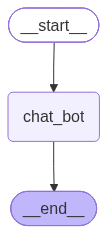

In [11]:
graph = StateGraph(State)

graph.add_node('chat_bot',chat_bot)

graph.add_edge(START,'chat_bot')
graph.add_edge('chat_bot',END)

graph_builder=graph.compile()

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [14]:
result = graph_builder.invoke({'messages':[('user', 'Hi, How are you?')]})

In [15]:
for m in result['messages']:
    print(f"{m.type}: {m.content}")

human: Hi, How are you?
ai: Hi! I’m doing well, thanks for asking 😊  
How are you doing today?


## Understanding `add_messages` reducer with a manual second turn

There is no checkpointer yet, so each `invoke()` call starts a fresh state.
To simulate multi-turn memory manually, we pass the previous `result['messages']`
back in as part of the new input, then add a new human turn. Watch how
`add_messages` appends the new turn onto the existing list rather than
replacing it.

In [16]:
print(f"Messages before second turn: {len(result['messages'])}")

# manually carry forward history since there's no checkpointer yet
result2 = graph_builder.invoke(
    {'messages': result['messages'] + [('user', 'What did I just ask you?')]}
)

print(f"Messages after second turn: {len(result2['messages'])}")

Messages before second turn: 2
Messages after second turn: 4


In [ ]:
for m in result2['messages']:
    print(f"{m.type}: {m.content}")

human: Hi, How are you?
ai: Hi! I’m doing well, thanks for asking 😊  
How are you doing today?
human: What did I just ask you?
ai: You asked: **“Hi, How are you?”**


In [18]:
state = {'messages': []}
while True:
    user_input = input("You: ")
    if user_input.lower() in ('exit', 'quit'):
        break
    state['messages'].append(('user', user_input))
    state = graph_builder.invoke(state)
    print(f"AI: {state['messages'][-1].content}")

AI: Hi! 👋 How can I help you today?
AI: I’m doing well, thanks for asking! 😊 How are you doing?
AI: I don’t have a personal name, but I’m ChatGPT.
AI: Nice to meet you, Tej! 😊 What would you like to do today?
AI: Your name is Tej.
AI: Because you told me earlier—“my name is tej.” I’m just repeating what you said.
AI: Not every time automatically, but **within this chat** I can see the conversation history so far, which is why I can remember things you told me earlier (like your name).

If you start a **new chat** or the system doesn’t include past messages, I may not have that history.
